seaborn.pairplot은 데이터의 변수 간 관계를 시각적으로 탐색하기 위한 도구로, 다음을 확인하는 데 유용합니다:

상관관계(correlation): 두 변수 간의 선형적 또는 비선형적 관계를 파악. <br>
군집(clustering): 데이터가 특정 패턴이나 그룹을 형성하는지 확인. <br>
이상치(outliers): 변수 간의 관계에서 벗어나는 점을 탐지. <br>

Pairplot에 적용할 데이터를 선택할 때, 두 변수가 상관관계(correlation)를 가지는지 여부를 먼저 검토하는 것이 중요합니다.

# 1. 상관계수 계산
# 2. Heatmap 시각화
# 3. Pairplot 생성
# 4. IQR 기준으로 이상치 탐지

Correlation Matrix:
          Feature1  Feature2  Feature3  Feature4
Feature1  1.000000  0.823486  0.553823  0.273799
Feature2  0.823486  1.000000  0.463929  0.146036
Feature3  0.553823  0.463929  1.000000  0.257985
Feature4  0.273799  0.146036  0.257985  1.000000


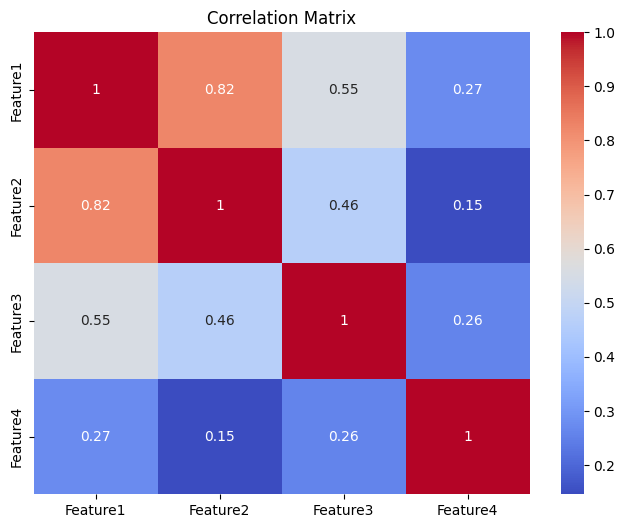

Strong Correlation Features: [('Feature1', 'Feature2'), ('Feature2', 'Feature1')]


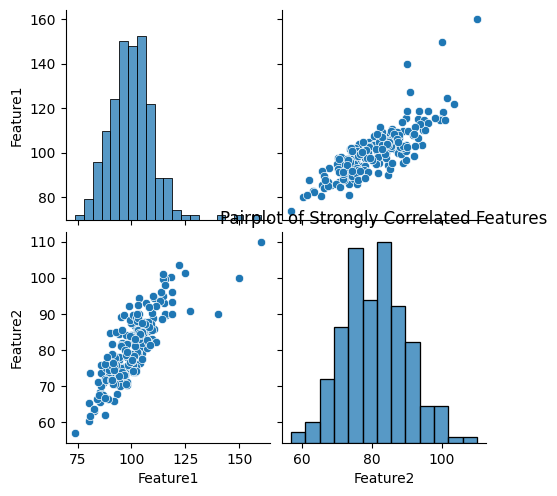

Outliers between Feature1 and Feature2:
       Feature1    Feature2   Feature3    Feature4
74    73.802549   56.941105  35.656199  248.193956
113  124.632421  101.378221  61.461236  154.804618
179  127.201692   90.767324  55.416020  274.536307
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  450.000000
202  160.000000  110.000000  90.000000  500.000000
Outliers between Feature2 and Feature1:
       Feature1    Feature2   Feature3    Feature4
74    73.802549   56.941105  35.656199  248.193956
113  124.632421  101.378221  61.461236  154.804618
179  127.201692   90.767324  55.416020  274.536307
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  450.000000
202  160.000000  110.000000  90.000000  500.000000
Moderately Correlated Features: [('Feature1', 'Feature3'), ('Feature2', 'Feature3'), ('Feature3', 'Feature1'), ('Feature3', 'Feature2')]


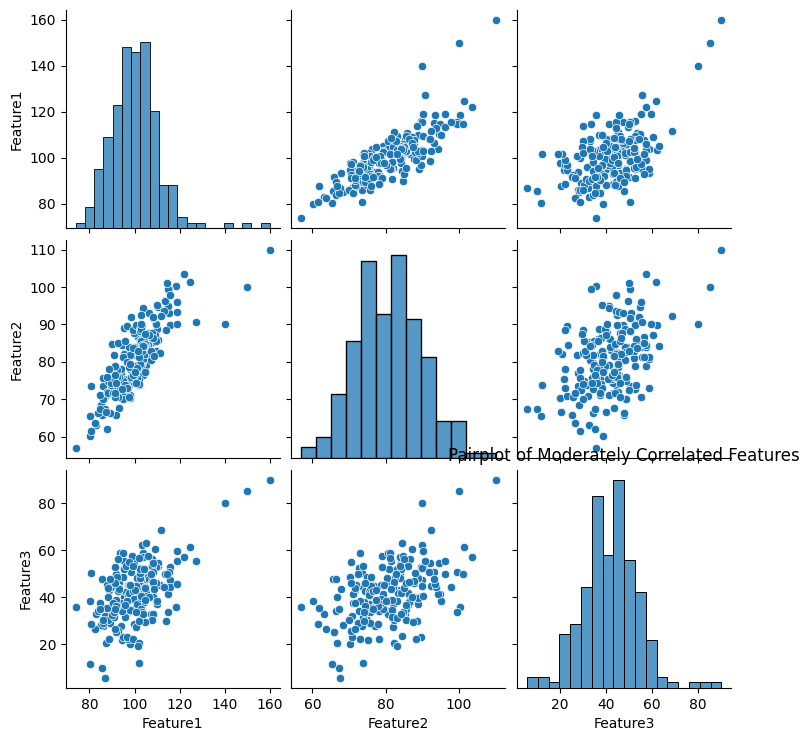

Outliers between Feature1 and Feature3:
       Feature1    Feature2   Feature3    Feature4
23    85.752518   67.364421  10.062214  195.083019
37    80.403299   65.361077  11.743971  133.298725
74    73.802549   56.941105  35.656199  248.193956
107  101.745778   73.817902  12.212885  203.800270
113  124.632421  101.378221  61.461236  154.804618
147   86.795434   67.469653   5.755620  249.602117
179  127.201692   90.767324  55.416020  274.536307
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  450.000000
202  160.000000  110.000000  90.000000  500.000000
Outliers between Feature2 and Feature3:
       Feature1    Feature2   Feature3    Feature4
23    85.752518   67.364421  10.062214  195.083019
37    80.403299   65.361077  11.743971  133.298725
107  101.745778   73.817902  12.212885  203.800270
147   86.795434   67.469653   5.755620  249.602117
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  450.000000
20

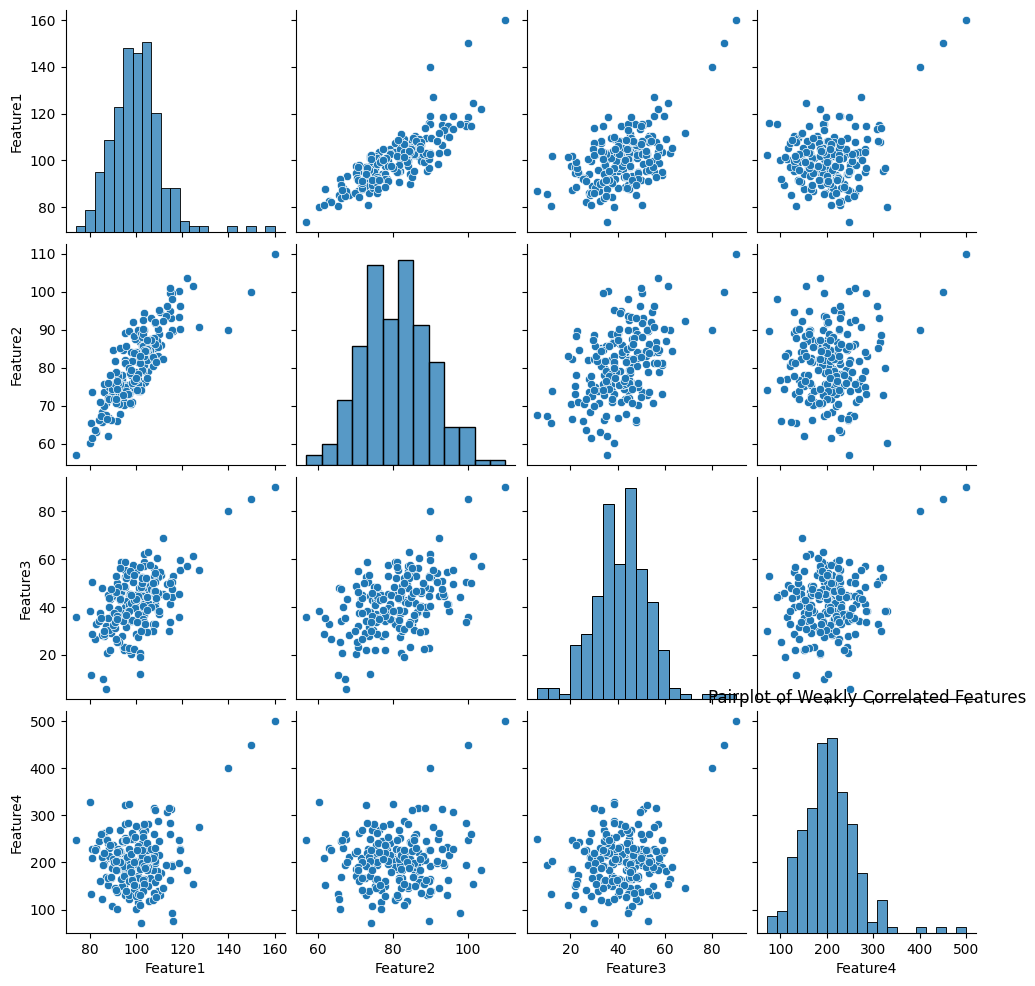

Outliers between Feature1 and Feature4:
       Feature1    Feature2   Feature3    Feature4
74    73.802549   56.941105  35.656199  248.193956
113  124.632421  101.378221  61.461236  154.804618
179  127.201692   90.767324  55.416020  274.536307
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  450.000000
202  160.000000  110.000000  90.000000  500.000000
Outliers between Feature2 and Feature4:
     Feature1  Feature2  Feature3  Feature4
200     140.0      90.0      80.0     400.0
201     150.0     100.0      85.0     450.0
202     160.0     110.0      90.0     500.0
Outliers between Feature3 and Feature4:
       Feature1    Feature2   Feature3    Feature4
23    85.752518   67.364421  10.062214  195.083019
37    80.403299   65.361077  11.743971  133.298725
107  101.745778   73.817902  12.212885  203.800270
147   86.795434   67.469653   5.755620  249.602117
200  140.000000   90.000000  80.000000  400.000000
201  150.000000  100.000000  85.000000  4

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
data = pd.DataFrame({
    "Feature1": np.random.normal(100, 10, 200),
    "Feature2": np.random.normal(50, 5, 200),
    "Feature3": np.random.uniform(30, 70, 200),
    "Feature4": np.random.normal(200, 50, 200),
})

# Feature 간 상관관계 추가 (Feature1과 Feature2를 강한 상관관계로 만듦)
data["Feature2"] = data["Feature1"] * 0.8 + np.random.normal(0, 5, 200)  # 강한 상관관계

data["Feature3"] = data["Feature1"] * 0.4 + np.random.normal(0, 10, 200)  # 중간 상관관계

data["Feature4"] = np.random.normal(200, 50, 200)  # 약한 상관관계

# 이상치 추가
outliers = pd.DataFrame({
    "Feature1": [140, 150, 160],
    "Feature2": [90, 100, 110],
    "Feature3": [80, 85, 90],
    "Feature4": [400, 450, 500],
})

# 이상치를 데이터에 추가
augmented_df = pd.concat([data, outliers], ignore_index=True)

# 1. 상관계수 계산
correlation_matrix = augmented_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# 2. Heatmap 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 이상치 탐지 함수
def find_outliers(df, feature_x, feature_y):
    # IQR 기준으로 이상치 탐지
    Q1_x = df[feature_x].quantile(0.25)
    Q3_x = df[feature_x].quantile(0.75)
    IQR_x = Q3_x - Q1_x
    lower_bound_x = Q1_x - 1.5 * IQR_x
    upper_bound_x = Q3_x + 1.5 * IQR_x

    Q1_y = df[feature_y].quantile(0.25)
    Q3_y = df[feature_y].quantile(0.75)
    IQR_y = Q3_y - Q1_y
    lower_bound_y = Q1_y - 1.5 * IQR_y
    upper_bound_y = Q3_y + 1.5 * IQR_y

    outliers = df[
        (~df[feature_x].between(lower_bound_x, upper_bound_x)) |
        (~df[feature_y].between(lower_bound_y, upper_bound_y))
    ]
    return outliers

# 3. 상관계수 기준에 따라 Pairplot 생성 및 이상치 탐지
# 강한 상관관계 (|r| > 0.7)
strong_corr_features = [(f1, f2) for f1 in augmented_df.columns for f2 in augmented_df.columns if f1 != f2 and abs(correlation_matrix[f1][f2]) > 0.7]
if strong_corr_features:
    print("Strong Correlation Features:", strong_corr_features)
    sns.pairplot(augmented_df, vars=list(set([f for pair in strong_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Strongly Correlated Features")
    plt.show()

    # 이상치 탐지
    for f1, f2 in strong_corr_features:
        outliers = find_outliers(augmented_df, f1, f2)
        print(f"Outliers between {f1} and {f2}:")
        print(outliers)

# 중간 정도의 상관관계 (0.3 < |r| <= 0.7)
moderate_corr_features = [(f1, f2) for f1 in augmented_df.columns for f2 in augmented_df.columns if f1 != f2 and 0.3 < abs(correlation_matrix[f1][f2]) <= 0.7]
if moderate_corr_features:
    print("Moderately Correlated Features:", moderate_corr_features)
    sns.pairplot(augmented_df, vars=list(set([f for pair in moderate_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Moderately Correlated Features")
    plt.show()

    # 이상치 탐지
    for f1, f2 in moderate_corr_features:
        outliers = find_outliers(augmented_df, f1, f2)
        print(f"Outliers between {f1} and {f2}:")
        print(outliers)

# 약한 상관관계 (|r| <= 0.3)
weak_corr_features = [(f1, f2) for f1 in augmented_df.columns for f2 in augmented_df.columns if f1 != f2 and abs(correlation_matrix[f1][f2]) <= 0.3]
if weak_corr_features:
    print("Weakly Correlated Features:", weak_corr_features)
    sns.pairplot(augmented_df, vars=list(set([f for pair in weak_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Weakly Correlated Features")
    plt.show()

    # 이상치 탐지
    for f1, f2 in weak_corr_features:
        outliers = find_outliers(augmented_df, f1, f2)
        print(f"Outliers between {f1} and {f2}:")
        print(outliers)
